In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
import seaborn as sns
sns.set_theme(context='notebook', style='ticks')
mpl.rcParams['figure.dpi'] = 150


### Request HPC Resources

In [5]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /user/anthony.meza/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://10.151.1.152:37739 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.151.1.152:37739,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion

datafiles = glob.glob(datadir("budget_sigma2_v1.2.0/CM4Xp125*"))[1:2]
mask_ds = xr.open_mfdataset(datafiles, engine = "zarr")

shelf_mask = (
    (mask_ds['geolat'] <= -50.0) * 
(mask_ds["deptho"].fillna(0.0) <= 1001.0))

grid = CM4Xutils.ds_to_grid(mask_ds)
regions = MaskRegions(shelf_mask, grid).region_dict
antarctic = regions[0] #there are more in this list if there are multiple contours 
region_mask = GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                       ij=(antarctic.i_c, antarctic.j_c)).mask

Inferring Z grid coordinate: density `sigma2`


In [10]:
native_path = datadir("transient_tracers_z")
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [11]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 150)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [12]:
z_i = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])
ds = ds.assign_coords({"z_i":z_i})

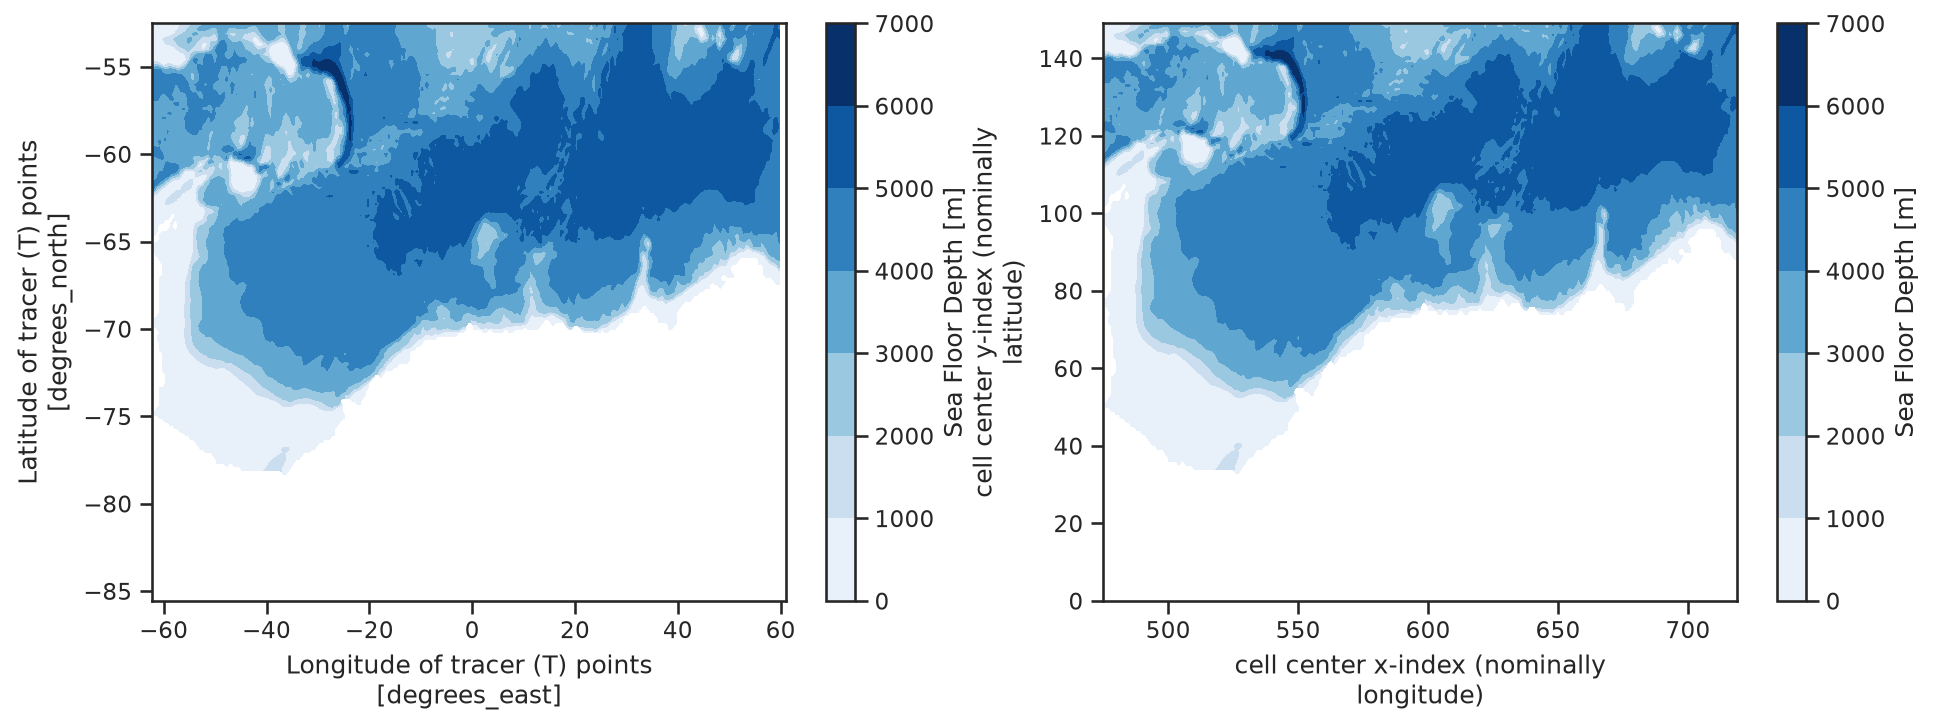

In [13]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, 1000))
ds_subset.deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat", cmap = "Blues")
ds_subset.deptho.plot.contourf(ax = ax[1], cmap = "Blues")

In [14]:
ds_subset = ds.ffill("z_l")
ds_subset = ds_subset.isel(z_l = -1).compute()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import cmocean.cm as cmo
def get_panel_labels(n):
    import string
    # This slices the alphabet string to the length you need
    return list(string.ascii_uppercase[:n])

def make_center_extended_cmap(
    levels,
    cmap_name="RdBu_r",
    center_value=0.0,
    zero_color=None,):
    levels = np.asarray(levels)

    base = plt.get_cmap(cmap_name)
    colors = base(np.linspace(0, 1, len(levels) - 1))

    if zero_color is None:
        zero_color = base(0.5)
    else:
        zero_color = mcolors.to_rgba(zero_color)

    center_matches = np.where(np.isclose(levels, center_value))[0]
    if len(center_matches) == 0:
        raise ValueError(f"center_value={center_value} must appear in levels.")

    center_idx = center_matches[0]
    if center_idx == 0 or center_idx == len(levels) - 1:
        raise ValueError("center_value cannot be the first or last level.")

    colors[center_idx - 1:center_idx + 1] = zero_color

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    return cmap, norm

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid val

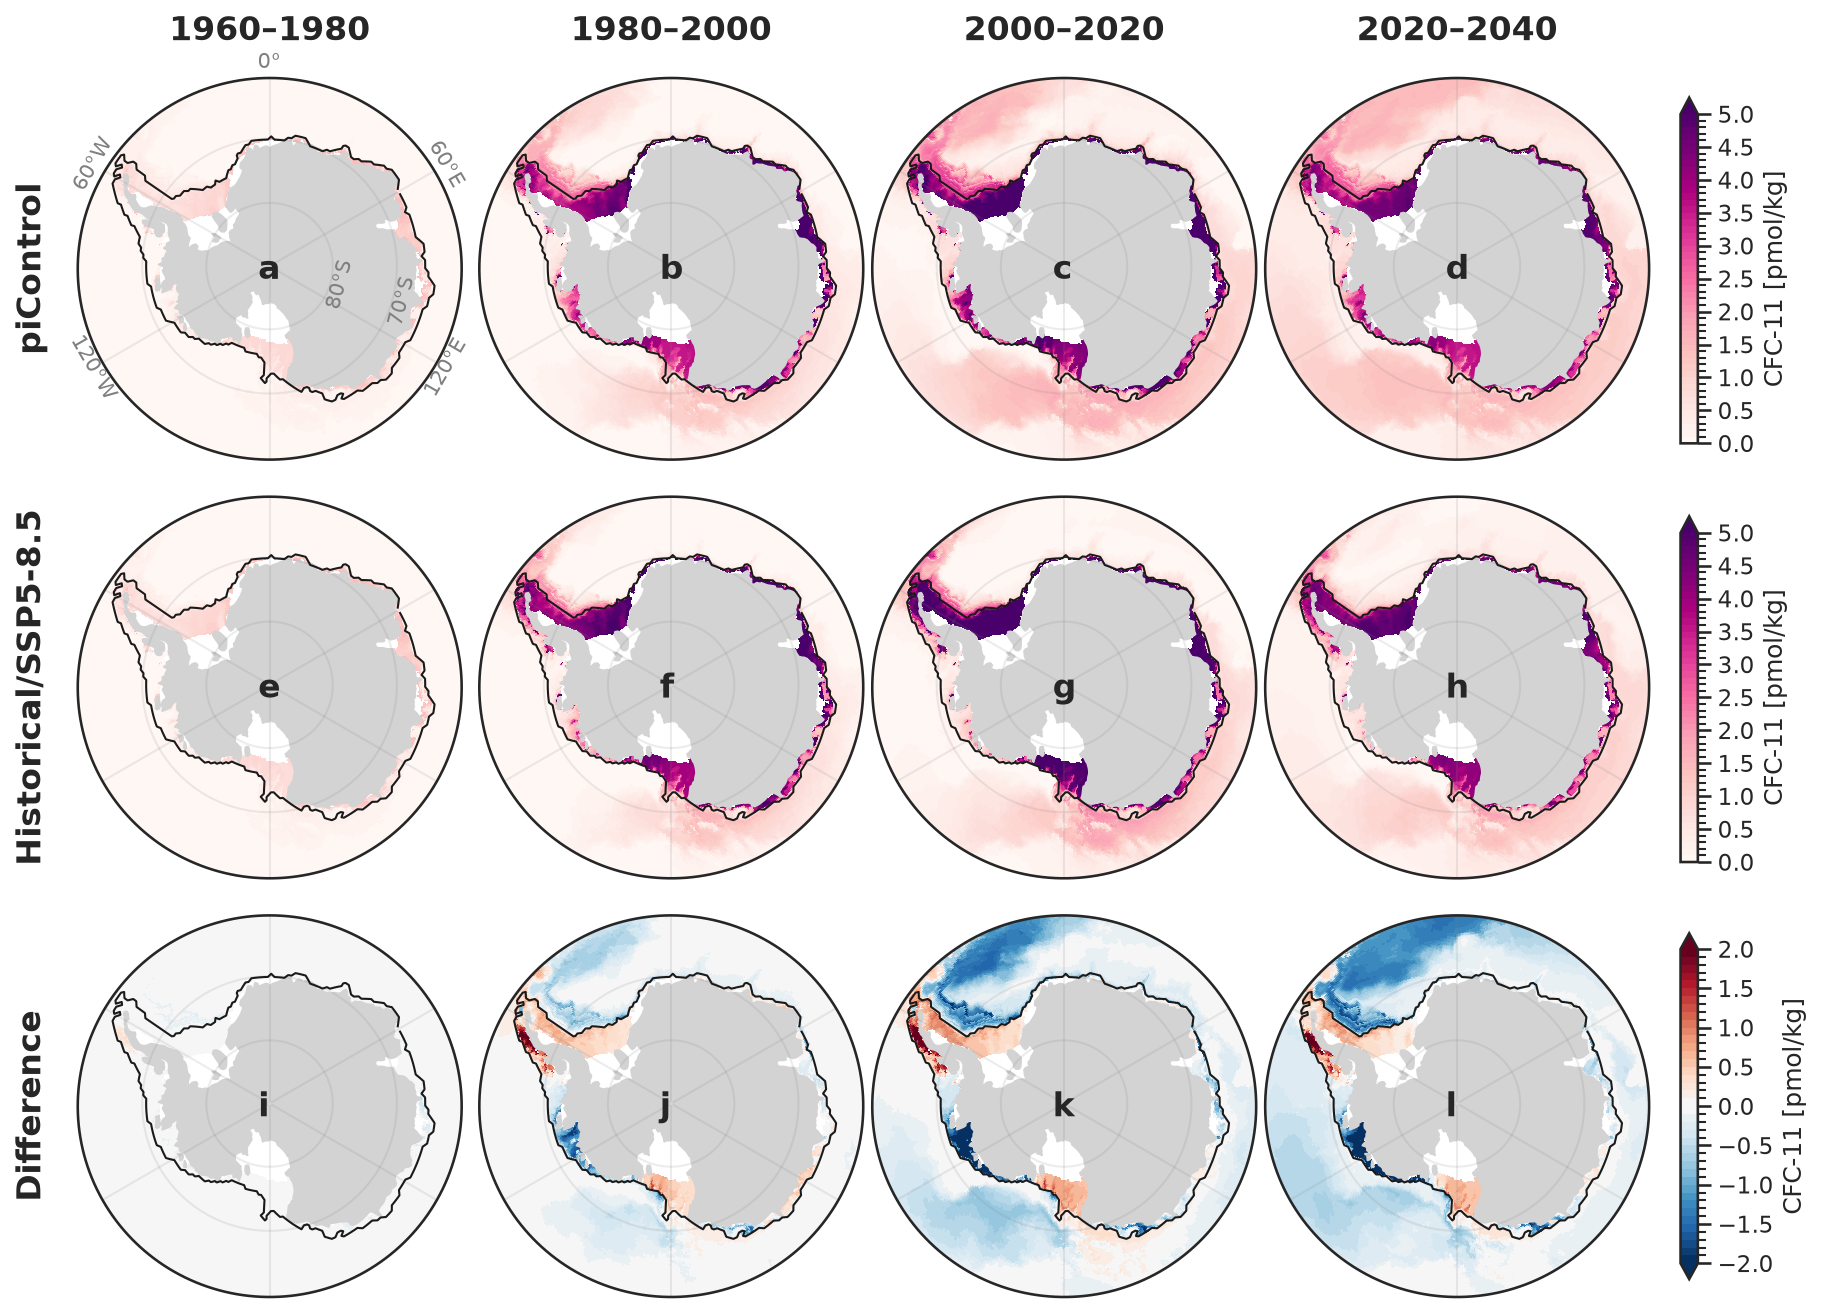

In [43]:
year_ranges = [(1960, 1980), (1980, 2000), (2000, 2020), (2020, 2040)]


plot_specs = [
    {
        "name": "cfc11",
        "data": ds_subset["cfc11"].sel(expt = "control") * 1e12 / 1035,
        "label": "CFC-11 [pmol/kg]",
        "levels": np.arange(0, 5.01, 0.1),
        "ticks": np.arange(0, 5.01, 0.5),
        "cmap": "RdPu",
        "extend":"max",
        "experiment":"piControl"
    },
    {
        "name": "cfc11",
        "data": ds_subset["cfc11"].sel(expt = "forced") * 1e12 / 1035,
        "label": "CFC-11 [pmol/kg]",
        "levels": np.arange(0, 5.01, 0.1),
        "ticks": np.arange(0, 5.01, 0.5),
        "cmap": "RdPu",
        "extend":"max",
        "experiment":"Historical/SSP5-8.5"
    },    
    {
        "name": "cfc11",
        "data": (ds_subset["cfc11"].sel(expt = "forced") -ds_subset["cfc11"].sel(expt = "control"))  * 1e12 / 1035,
        "label": "CFC-11 [pmol/kg]",
        "levels": np.arange(-2, 2.01, 0.1),
        "ticks": np.arange(-2, 2.01, 0.5),
        "cmap": "RdBu_r",
        "extend":"both",
        "experiment":"Difference"
    },    
]

nrows = len(plot_specs)
ncols = len(year_ranges)

fig, ax = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.9 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.005, wspace=0.02, hspace=0.005)
ax = np.atleast_2d(ax)

panel_labels = get_panel_labels(ncols * nrows)

k = -1
for row, spec in enumerate(plot_specs):
    da = spec["data"]
    label = spec["label"]
    levels = spec["levels"]
    ticks = spec["ticks"]
    cmap_name = spec["cmap"]
    extend = spec.get("extend", "both")
    experiment_name = spec["experiment"]

    if experiment_name == "Difference":
        cmap, norm = make_center_extended_cmap(levels, cmap_name=cmap_name)
    else:
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend=extend)


    for col, year_range in enumerate(year_ranges):
        k+=1
        start_year, end_year = year_range
        this_ax = ax[row, col]

        this_ax.set_extent([-180, 180, -90, -56], ccrs.PlateCarree())

        data_decade = da.sel(year=slice(start_year, end_year)).mean("year")

        if row == 0 and col == 0:
            draw_labels = True
        else: 
            draw_labels = False
        cm = plot_antarctic(data_decade, this_ax, cmap=cmap, norm = norm, mask_threshold=-np.inf, draw_labels = draw_labels)
        
        # this_ax.text(-70,-77.0,'Weddell',fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text( 70,-79.0,'Prydz'  ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(155,-72.0,'Adélie' ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(195,-79.0,'Ross'   ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        if row == 0:
            this_ax.set_title(f"{start_year}–{end_year}", pad=9, fontweight = "bold", fontsize = 16, y = 1.05)
        if col == 0:
            ax[row, col].text(
                        -0.12, 0.5, experiment_name,
                        transform=ax[row, 0].transAxes,
                        rotation=90,
                        va="center",
                        ha="center",
                        fontsize=16,
                        fontweight="bold",)
            
        ax[row, col].contour(region_mask.geolon, region_mask.geolat, 1.0 * region_mask, 
                         levels = [0.5], transform=ccrs.PlateCarree(), 
                             linewidth = 1.0, 
                         colors = "k", zorder = 100)
        this_ax.text(
            0.47,
            0.54,
            panel_labels[k].lower(),
            transform=this_ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold",
            zorder=300,
        )
    
    cbar = fig.colorbar(cm, ax=ax[row, :], orientation="vertical", ticks=ticks, 
                        fraction=0.011, pad=0.02, label = label, extend = extend)

fig.savefig("plots/S7.bottom_CFC11_spatial.png", dpi = 350, bbox_inches = "tight")

/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/user/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid val

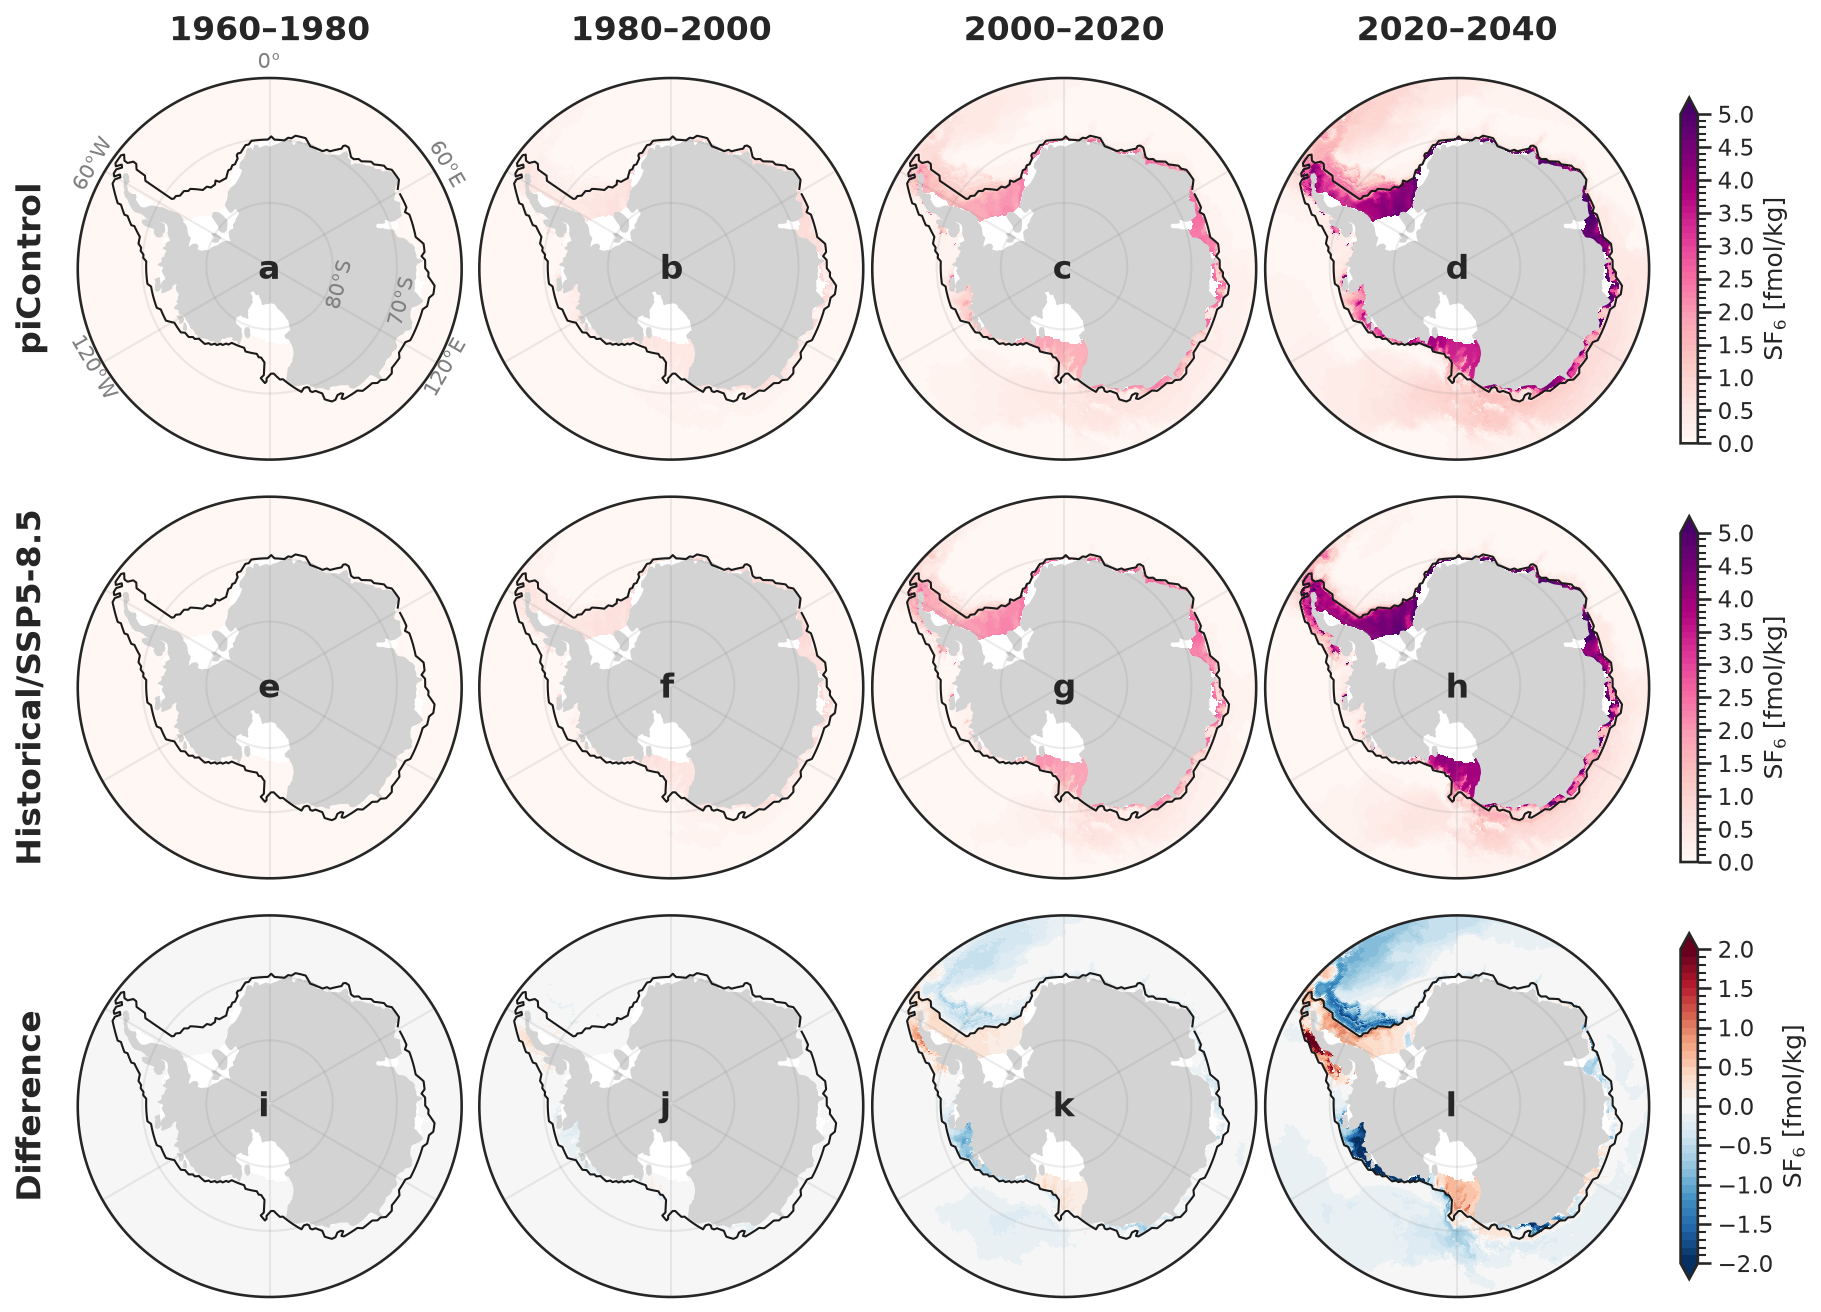

In [39]:
plot_specs = [
    {
        "name": "sf6",
        "data": ds_subset["sf6"].sel(expt = "control") * 1e12 / 1035 * 1e3 ,
        "label": r"SF$_6$ [fmol/kg]",
        "levels": np.arange(0, 5.01, 0.1),
        "ticks": np.arange(0, 5.01, 0.5),
        "cmap": "RdPu",
        "extend":"max",
        "experiment":"piControl"
    },
    {
        "name": "sf6",
        "data": ds_subset["sf6"].sel(expt = "forced") * 1e12 / 1035 * 1e3 ,
        "label": r"SF$_6$ [fmol/kg]",
        "levels": np.arange(0, 5.01, 0.1),
        "ticks": np.arange(0, 5.01, 0.5),
        "cmap": "RdPu",
        "extend":"max",
        "experiment":"Historical/SSP5-8.5"
    },    
    {
        "name": "sf6",
        "data": (ds_subset["sf6"].sel(expt = "forced") -ds_subset["sf6"].sel(expt = "control"))  * 1e12 / 1035 * 1e3 ,
        "label": r"SF$_6$ [fmol/kg]",
        "levels": np.arange(-2, 2.01, 0.1),
        "ticks": np.arange(-2, 2.01, 0.5),
        "cmap": "RdBu_r",
        "extend":"both",
        "experiment":"Difference"
    },    
]

nrows = len(plot_specs)
ncols = len(year_ranges)

fig, ax = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.9 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.005, wspace=0.02, hspace=0.005)
ax = np.atleast_2d(ax)

panel_labels = get_panel_labels(ncols * nrows)

k = -1
for row, spec in enumerate(plot_specs):
    da = spec["data"]
    label = spec["label"]
    levels = spec["levels"]
    ticks = spec["ticks"]
    cmap_name = spec["cmap"]
    extend = spec.get("extend", "both")
    experiment_name = spec["experiment"]

    if experiment_name == "Difference":
        cmap, norm = make_center_extended_cmap(levels, cmap_name=cmap_name)
    else:
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend=extend)

    for col, year_range in enumerate(year_ranges):
        k+=1
        start_year, end_year = year_range
        this_ax = ax[row, col]

        this_ax.set_extent([-180, 180, -90, -56], ccrs.PlateCarree())

        data_decade = da.sel(year=slice(start_year, end_year)).mean("year")
        if row == 0 and col == 0:
            draw_labels = True
        else: 
            draw_labels = False
        cm = plot_antarctic(data_decade, this_ax, cmap=cmap, norm = norm, mask_threshold=-np.inf, draw_labels = draw_labels)
        
        # this_ax.text(-70,-77.0,'Weddell',fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text( 70,-79.0,'Prydz'  ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(155,-72.0,'Adélie' ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(195,-79.0,'Ross'   ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        if row == 0:
            this_ax.set_title(f"{start_year}–{end_year}", pad=9, fontweight = "bold", fontsize = 16, y = 1.05)
        if col == 0:
            ax[row, col].text(
                        -0.12, 0.5, experiment_name,
                        transform=ax[row, 0].transAxes,
                        rotation=90,
                        va="center",
                        ha="center",
                        fontsize=16,
                        fontweight="bold",
                        )
            
        ax[row, col].contour(region_mask.geolon, region_mask.geolat, 1.0 * region_mask, 
                         levels = [0.5], transform=ccrs.PlateCarree(), 
                             linewidth = 1.0, 
                         colors = "k", zorder = 100)
        
        this_ax.text(
            0.47,
            0.54,
            panel_labels[k].lower(),
            transform=this_ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold",
            zorder=300,
        )
    
    cbar = fig.colorbar(cm, ax=ax[row, :], orientation="vertical", ticks=ticks, 
                        fraction=0.011, pad=0.02, label = label, extend = extend)

fig.savefig("plots/S7.bottom_SF6_spatial.png", dpi = 350, bbox_inches = "tight")

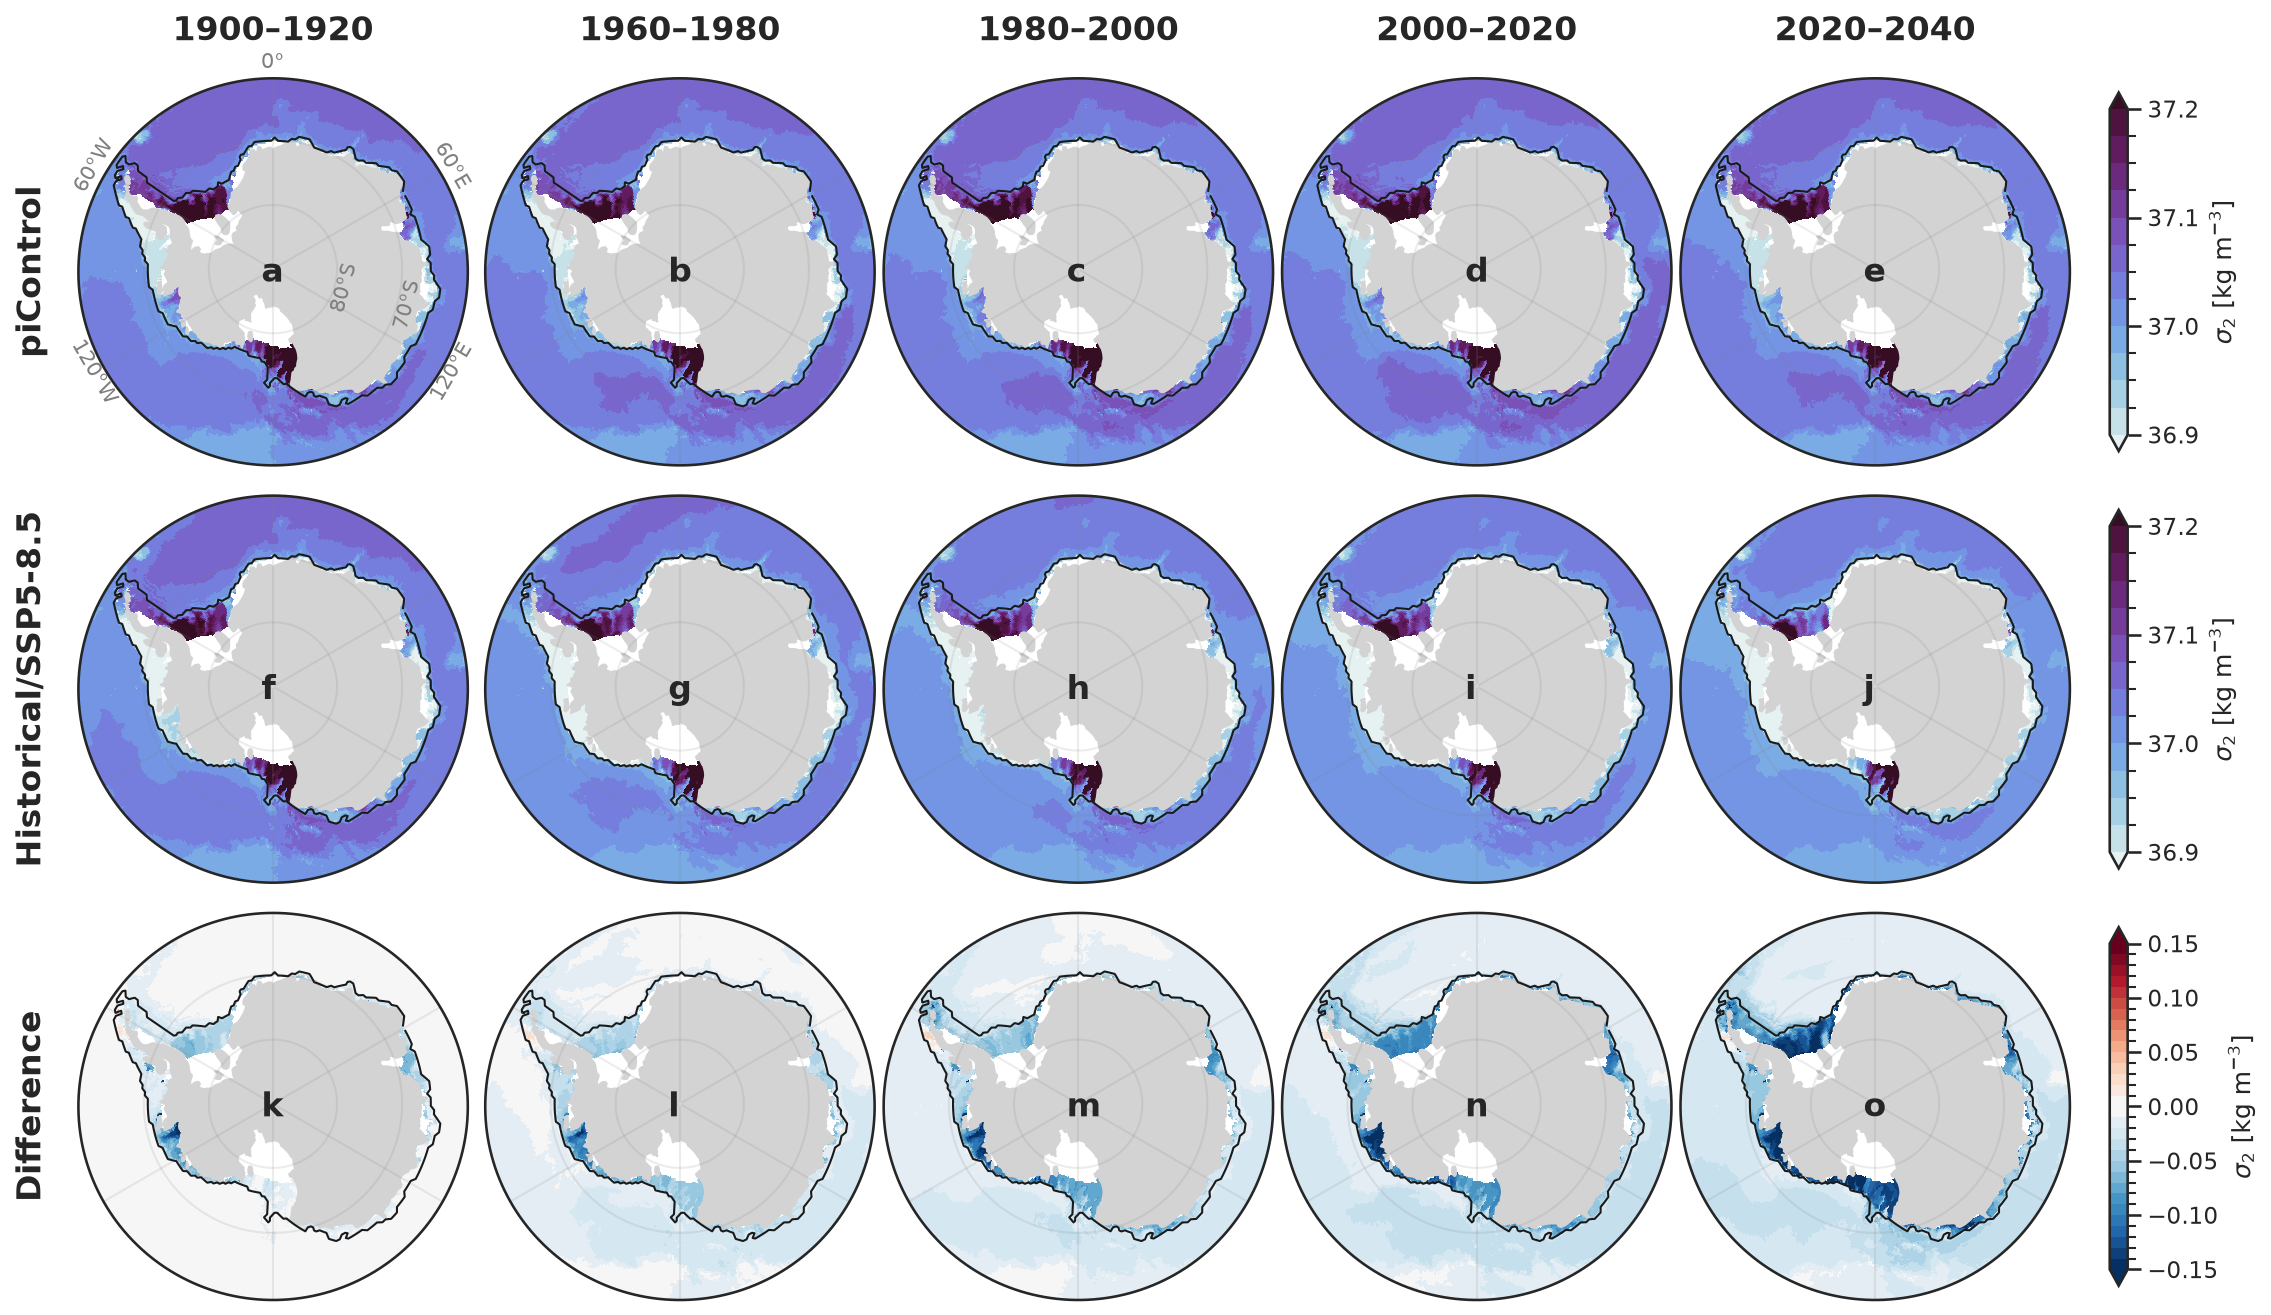

In [42]:
plot_specs = [
    {
        "name": "sigma2_offline",
        "data": ds_subset["sigma2_offline"].sel(expt = "control"),
        "label": r"$\sigma_2$ [kg m$^{-3}$]",
        "levels": np.arange(36.9, 37.2 + 1e-16, 0.025),
        "ticks": np.arange(36.9, 37.2 + 1e-16, 0.1),
        "cmap": cmo.dense,
        "extend":"both",
        "experiment":"piControl"
    },
    {
        "name": "sigma2_offline",
        "data": ds_subset["sigma2_offline"].sel(expt = "forced"),
        "label": r"$\sigma_2$ [kg m$^{-3}$]",
        "levels": np.arange(36.9, 37.2 + 1e-16, 0.025),
        "ticks": np.arange(36.9, 37.2 + 1e-16, 0.1),
        "cmap": cmo.dense,
        "extend":"both",
        "experiment":"Historical/SSP5-8.5"
    },
    {
        "name": "sigma2_offline",
        "data": (ds_subset["sigma2_offline"].sel(expt = "forced") -ds_subset["sigma2_offline"].sel(expt = "control")),
        "label": r"$\sigma_2$ [kg m$^{-3}$]",
        "levels": np.arange(-0.15, .15 + 1e-16, 0.01),
        "ticks": np.arange(-0.15, .15+ 1e-16, 0.05),
        "cmap": "RdBu_r",
        "extend":"both",
        "experiment":"Difference"
    },    
]

year_ranges = [(1900, 1920), (1960, 1980), (1980, 2000), (2000, 2020), (2020, 2040)]


nrows = len(plot_specs)
ncols = len(year_ranges)

fig, ax = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.9 * nrows),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()},
                       constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.01, wspace=0.02, hspace=0.01)
ax = np.atleast_2d(ax)

panel_labels = get_panel_labels(ncols * nrows)

k = -1
for row, spec in enumerate(plot_specs):
    da = spec["data"]
    label = spec["label"]
    levels = spec["levels"]
    ticks = spec["ticks"]
    cmap_name = spec["cmap"]
    extend = spec.get("extend", "both")
    experiment_name = spec["experiment"]

    if experiment_name == "Difference":
        cmap, norm = make_center_extended_cmap(levels, cmap_name=cmap_name)
    else:
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend=extend)

    for col, year_range in enumerate(year_ranges):
        k+=1
        start_year, end_year = year_range
        this_ax = ax[row, col]

        this_ax.set_extent([-180, 180, -90, -56], ccrs.PlateCarree())

        data_decade = da.sel(year=slice(start_year, end_year)).mean("year")

        if row == 0 and col == 0:
            draw_labels = True
        else: 
            draw_labels = False
            
        cm = plot_antarctic(data_decade, this_ax, cmap=cmap, norm = norm, mask_threshold=-np.inf, draw_labels = draw_labels)
        
        # this_ax.text(-70,-77.0,'Weddell',fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text( 70,-79.0,'Prydz'  ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(155,-72.0,'Adélie' ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        # this_ax.text(195,-79.0,'Ross'   ,fontsize=7,color="k",transform=ccrs.PlateCarree(),zorder=200)
        if row == 0:
            this_ax.set_title(f"{start_year}–{end_year}", pad=9, fontweight = "bold", fontsize = 16, y = 1.05)
        if col == 0:
            ax[row, col].text(
                        -0.12, 0.5, experiment_name,
                        transform=ax[row, 0].transAxes,
                        rotation=90,
                        va="center",
                        ha="center",
                        fontsize=16,
                        fontweight="bold",
                        )
        ax[row, col].contour(region_mask.geolon, region_mask.geolat, 1.0 * region_mask, 
                     levels = [0.5], transform=ccrs.PlateCarree(), 
                     linewidth = 1.0, colors = "k", zorder = 100)
        this_ax.text(
            0.47,
            0.54,
            panel_labels[k].lower(),
            transform=this_ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold",
            zorder=300,
        )
    
    cbar = fig.colorbar(cm, ax=ax[row, :], orientation="vertical", ticks=ticks, 
                        fraction=0.009, pad=0.02, label = label, extend = extend)

fig.savefig("plots/S7.bottom_density_spatial.png", dpi = 350, bbox_inches = "tight")